In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:02<00:00, 8.85MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 191kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.5MB/s]

Train samples: 60000
Test samples: 10000


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [ ]:
model = VAE(latent_dim=2).to(device)
print(model)


VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
)


In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


In [ ]:
print("VAE loss (with KL) defined")


VAE loss (with KL) defined


In [ ]:
def ae_loss(recon_x, x):
    return F.binary_cross_entropy(recon_x, x, reduction="sum")


In [ ]:
print("Autoencoder loss (without KL) defined")


Autoencoder loss (without KL) defined


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = vae_loss(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[VAE] Epoch {epoch+1}, Loss: {total_loss / len(train_dataset):.4f}")


[VAE] Epoch 1, Loss: 259.1698
[VAE] Epoch 2, Loss: 259.0667
[VAE] Epoch 3, Loss: 259.0208
[VAE] Epoch 4, Loss: 258.9735
[VAE] Epoch 5, Loss: 258.9341
[VAE] Epoch 6, Loss: 258.8708
[VAE] Epoch 7, Loss: 258.8231
[VAE] Epoch 8, Loss: 258.8417
[VAE] Epoch 9, Loss: 258.7488
[VAE] Epoch 10, Loss: 258.6569
[VAE] Epoch 11, Loss: 258.6772
[VAE] Epoch 12, Loss: 258.5917
[VAE] Epoch 13, Loss: 258.5694
[VAE] Epoch 14, Loss: 258.5247
[VAE] Epoch 15, Loss: 258.4564
[VAE] Epoch 16, Loss: 258.4515
[VAE] Epoch 17, Loss: 258.3816
[VAE] Epoch 18, Loss: 258.3635
[VAE] Epoch 19, Loss: 258.3552
[VAE] Epoch 20, Loss: 258.3255
[VAE] Epoch 21, Loss: 258.2406
[VAE] Epoch 22, Loss: 258.2337
[VAE] Epoch 23, Loss: 258.2488
[VAE] Epoch 24, Loss: 258.1211
[VAE] Epoch 25, Loss: 258.1072
[VAE] Epoch 26, Loss: 258.0824
[VAE] Epoch 27, Loss: 258.0080
[VAE] Epoch 28, Loss: 258.0443
[VAE] Epoch 29, Loss: 258.0025
[VAE] Epoch 30, Loss: 257.9450
[VAE] Epoch 31, Loss: 257.8957
[VAE] Epoch 32, Loss: 257.8596
[VAE] Epoch 33, L

In [ ]:
model_ae = VAE(latent_dim=2).to(device)
optimizer_ae = optim.Adam(model_ae.parameters(), lr=0.001)

model_ae.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer_ae.zero_grad()
        recon, _, _ = model_ae(data)
        loss = ae_loss(recon, data)

        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()

    print(f"[AE ] Epoch {epoch+1}, Loss: {total_loss / len(train_dataset):.4f}")


[AE ] Epoch 1, Loss: 290.6580
[AE ] Epoch 2, Loss: 266.6437
[AE ] Epoch 3, Loss: 262.9537
[AE ] Epoch 4, Loss: 260.8666
[AE ] Epoch 5, Loss: 259.4858
[AE ] Epoch 6, Loss: 258.4584
[AE ] Epoch 7, Loss: 257.6403
[AE ] Epoch 8, Loss: 256.9269
[AE ] Epoch 9, Loss: 256.3375
[AE ] Epoch 10, Loss: 255.7961
[AE ] Epoch 11, Loss: 255.3781
[AE ] Epoch 12, Loss: 255.0753
[AE ] Epoch 13, Loss: 254.6799
[AE ] Epoch 14, Loss: 254.3089
[AE ] Epoch 15, Loss: 254.0753
[AE ] Epoch 16, Loss: 253.6770
[AE ] Epoch 17, Loss: 253.3779
[AE ] Epoch 18, Loss: 253.1565
[AE ] Epoch 19, Loss: 252.9277
[AE ] Epoch 20, Loss: 252.7222
[AE ] Epoch 21, Loss: 252.4472
[AE ] Epoch 22, Loss: 252.3185
[AE ] Epoch 23, Loss: 252.1430
[AE ] Epoch 24, Loss: 251.9525
[AE ] Epoch 25, Loss: 251.8517
[AE ] Epoch 26, Loss: 251.6875
[AE ] Epoch 27, Loss: 251.5840
[AE ] Epoch 28, Loss: 251.4836
[AE ] Epoch 29, Loss: 251.3380
[AE ] Epoch 30, Loss: 251.2924
[AE ] Epoch 31, Loss: 251.0675
[AE ] Epoch 32, Loss: 250.9958
[AE ] Epoch 33, L

In [ ]:
model.eval()
with torch.no_grad():
    z = torch.randn(10, 2).to(device)
    samples_vae = model.decode(z)


In [ ]:
model_ae.eval()
with torch.no_grad():
    z = torch.randn(10, 2).to(device)
    samples_ae = model_ae.decode(z)


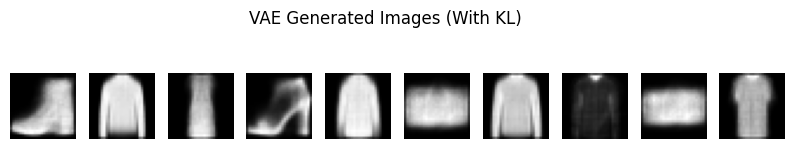

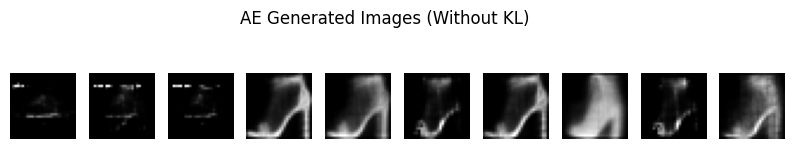

In [ ]:
def show_images(samples, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(samples[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(samples_vae, "VAE Generated Images (With KL)")
show_images(samples_ae, "AE Generated Images (Without KL)")
